# 03 — Factor Analysis & Diagnostics

**AI Exposure Factor Suite — Part 1 (ETF-based factors)**

This notebook analyzes the two market-implied AI return factors produced by the construction pipeline:

1. **AI Theme Factor** ($F_{AITheme}$) — lagged-AUM-weighted basket of AI-theme ETF **excess** returns:
$$F_{AITheme,t} = \sum_{e \in \text{Theme}} w_{e,t-1}\,\big(R_{e,t} - R_{f,t}\big)$$
2. **AI Infrastructure Factor** ($F_{AIInfra}$) — semiconductor ETF (SOXX) **excess** return:
$$F_{AIInfra,t} = R_{SOXX,t} - R_{f,t}$$

where the daily risk-free rate is the annualized 3-month T-bill rate divided by 252, forward-filled from monthly observations.

**Contents**
1. Factor overview (coverage, observation counts)
2. Performance: summary statistics, growth of \$1, drawdowns
3. Return distributions and rolling volatility
4. Correlation analysis and multicollinearity diagnostics
5. Factor regressions (CAPM and FF5+UMD, Newey–West errors)
6. Regime analysis: pre- vs post-ChatGPT
7. Robustness: SOXX- vs SMH-based infrastructure factor
8. Pipeline diagnostics table
9. Key takeaways

The notebook runs **offline** against the already-fetched Feather files under `data/`.

## Setup

One import cell. Paths are anchored to the project root (the notebook lives in `notebooks/`, and `nbconvert` executes with the notebook's directory as CWD, so we resolve `..` explicitly rather than relying on `os.chdir`).

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# pandas 2.3 routes read_feather through pyarrow.feather.read_feather, which
# pyarrow >=24 deprecates with a noisy FutureWarning. It is harmless for our
# pinned environment, so we silence just that message.
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message=".*pyarrow.feather.read_feather is deprecated.*",
)

PROJECT_ROOT = Path("..").resolve()
DATA = PROJECT_ROOT / "data"

TRADING_DAYS = 252
CHATGPT_DATE = pd.Timestamp("2022-11-30")  # ChatGPT release — regime split used in the spec

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 1. Factor overview

We load the daily factor file and confirm coverage. The AI Theme factor starts on **2013-10-23** because the basket can only contain ETFs that actually exist: the first theme ETF is ROBO (inception 2013-10-22, first daily return 2013-10-23). This is *point-in-time inclusion* — an ETF enters the basket only when return data for it is available, so there is no pre-inception backfill. The AI Infra factor starts on **2010-01-05**, the first SOXX return in the sample.

**Data notes (issues found during this analysis, since fixed in the pipeline):**

- An earlier version of the factor file had a NaN `rf_rate` column before 2013-11-01 and, consequently, 19 leading NaN AI Infra rows in January 2010 — the risk-free forward-fill window started too late. The pipeline now starts the rf forward-fill 45 days before the first return date, so `rf_rate` has **zero NaN** across the whole file and the infra factor is valid from 2010-01-05.
- The theme basket previously showed an exact 0.0 row on ROBO's inception day (2013-10-22). The aggregation now uses `sum(min_count=1)`, so that row is correctly NaN and the theme factor has 3,182 valid observations with no zero-artifact rows.
- The daily risk-free rate itself is small but real: the ~0.11%/yr levels embedded in the early sample are the actual ZIRP-era 3-month T-bill rates, not a fill artifact.

In [2]:
factors = pd.read_feather(DATA / "factors" / "ai_factor_daily.feather")
factors["date"] = pd.to_datetime(factors["date"]).dt.normalize()
factors = factors.sort_values("date").reset_index(drop=True)

theme = factors.dropna(subset=["ai_theme_excess_return"])
infra = factors.dropna(subset=["ai_infra_excess_return"])

print(f"File coverage          : {factors['date'].min():%Y-%m-%d} -> {factors['date'].max():%Y-%m-%d} ({len(factors):,} rows)")
print(f"AI Theme (excess)      : {theme['date'].min():%Y-%m-%d} -> {theme['date'].max():%Y-%m-%d} ({len(theme):,} obs)")
print(f"AI Infra (excess)      : {infra['date'].min():%Y-%m-%d} -> {infra['date'].max():%Y-%m-%d} ({len(infra):,} obs)")
print(f"Active theme ETFs at end: {int(factors['active_theme_etf_count'].iloc[-1])} of 7 classified theme ETFs")

# Also load the Fama-French daily factors (decimal units) used throughout.
ff = pd.read_feather(DATA / "reference" / "ff_factors_daily.feather")
ff["date"] = pd.to_datetime(ff["date"]).dt.normalize()
ff = ff[["date", "mkt_rf", "smb", "hml", "rmw", "cma", "rf", "umd"]].sort_values("date").reset_index(drop=True)

merged = factors.merge(ff, on="date", how="left")
print(f"FF daily file          : {ff['date'].min():%Y-%m-%d} -> {ff['date'].max():%Y-%m-%d} "
      f"(5-factor columns end {ff.dropna(subset=['rmw'])['date'].max():%Y-%m-%d}; NaN after)")

File coverage          : 2010-01-04 -> 2026-06-18 (4,140 rows)
AI Theme (excess)      : 2013-10-23 -> 2026-06-18 (3,182 obs)
AI Infra (excess)      : 2010-01-05 -> 2026-06-18 (4,139 obs)
Active theme ETFs at end: 7 of 7 classified theme ETFs
FF daily file          : 1926-11-03 -> 2026-05-29 (5-factor columns end 2026-05-29; NaN after)


## 2. Performance

Daily statistics are annualized with the standard 252-trading-day scaling:

$$\bar{R}_{ann} = 252\,\bar{R}_d, \qquad \sigma_{ann} = \sqrt{252}\,\sigma_d, \qquad \text{Sharpe} = \frac{\bar{R}^{xs}_d}{\sigma_d}\sqrt{252}$$

The Sharpe ratio is computed directly from the **excess** return columns, which already subtract the daily risk-free rate stored in the factor file (`rf_rate`, now populated for the full sample). Max drawdown is measured on the compounded excess-return stream, i.e. the equity curve of a \$1 investment in the (self-financing, long–short) factor portfolio.

> **Methodology note (documented fix):** an earlier pipeline version subtracted the *annual* T-bill rate from *daily* returns, biasing daily excess returns down by roughly the full annual rate (mean daily "excess" return ≈ −1.79%/day). The current pipeline divides the annual rate by 252 before subtracting, and the excess returns below are correctly centered.

In [3]:
def max_drawdown(r: pd.Series) -> float:
    """Max drawdown of the compounded return stream r."""
    cum = (1 + r).cumprod()
    return (cum / cum.cummax() - 1).min()


def performance_stats(df: pd.DataFrame, col: str) -> pd.Series:
    r = df[col].dropna()
    dates = df.loc[r.index, "date"]
    return pd.Series({
        "start": dates.min().strftime("%Y-%m-%d"),
        "end": dates.max().strftime("%Y-%m-%d"),
        "obs": len(r),
        "ann_mean": r.mean() * TRADING_DAYS,
        "ann_vol": r.std() * np.sqrt(TRADING_DAYS),
        "sharpe": r.mean() / r.std() * np.sqrt(TRADING_DAYS),
        "skew": r.skew(),
        "excess_kurtosis": r.kurt(),
        "min_daily": r.min(),
        "max_daily": r.max(),
        "max_drawdown": max_drawdown(r),
    })


perf = pd.DataFrame({
    "AI Theme (excess)": performance_stats(factors, "ai_theme_excess_return"),
    "AI Infra (excess)": performance_stats(factors, "ai_infra_excess_return"),
})
perf

,AI Theme (excess),AI Infra (excess)
start,2013-10-23,2010-01-05
end,2026-06-18,2026-06-18
obs,3182,4139
ann_mean,0.1520,0.2644
ann_vol,0.2266,0.3035
sharpe,0.6707,0.8710
skew,-0.2146,-0.0068
excess_kurtosis,5.6667,5.6595
min_daily,-0.1053,-0.1523
max_daily,0.1227,0.1855


The annualized mean and volatility match the pipeline diagnostics (AI Theme ≈ 15.2% / 22.7%, AI Infra ≈ 26.4% / 30.4%), confirming the notebook reproduces the stored factor series exactly. Both factors show the fat tails typical of daily equity returns (excess kurtosis ≈ 5.7) and near-zero to mildly negative skew. On a risk-adjusted basis the semiconductor (infra) factor has the higher Sharpe (≈0.87 vs ≈0.67 annualized), while both factors suffered similar maximum drawdowns of roughly −46% (infra) to −48% (theme).

### Growth of \$1

The chart compounds each factor's **excess** return stream (growth of \$1 in the self-financing factor portfolio) against the **total** US market return, $R_{mkt,t} = \text{MKT\_RF}_t + RF_t$, from the FF daily file. The comparison is over the AI Theme sample (from 2013-10-23) so all three lines share one starting point. Note the slight apples-to-oranges caveat: the factor lines are excess returns of long–short style portfolios, while the market line is a fully-invested total return.

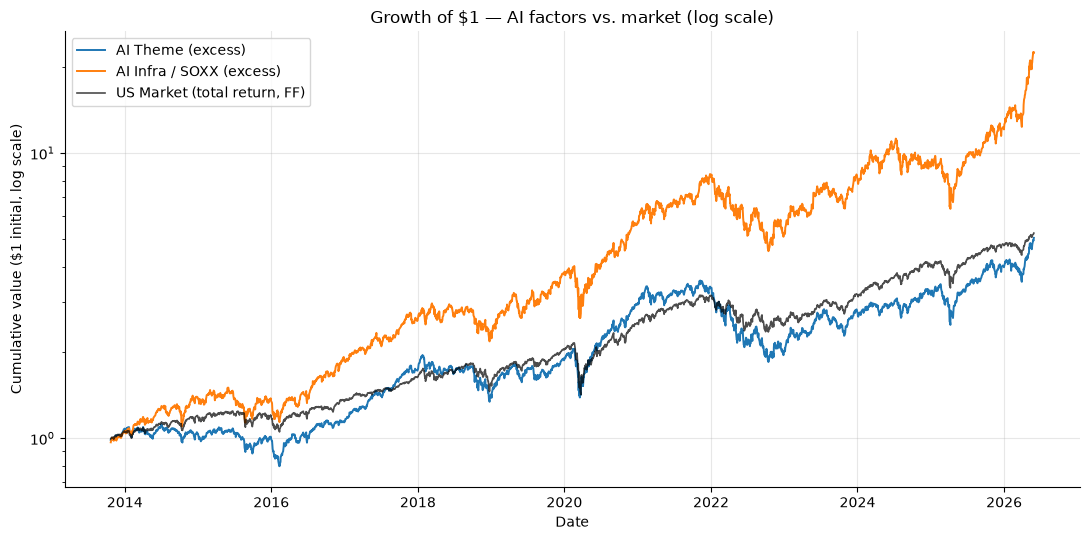

Final values over 2013-10-23 -> 2026-05-29: AI Theme $5.04, AI Infra $22.56, Market $5.24


In [4]:
plot_df = merged.loc[merged["date"] >= theme["date"].min(),
                     ["date", "ai_theme_excess_return", "ai_infra_excess_return", "mkt_rf", "rf"]].dropna()
plot_df = plot_df.assign(mkt_total=plot_df["mkt_rf"] + plot_df["rf"])

growth = (1 + plot_df[["ai_theme_excess_return", "ai_infra_excess_return", "mkt_total"]]).cumprod()

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(plot_df["date"], growth["ai_theme_excess_return"], label="AI Theme (excess)", lw=1.4)
ax.plot(plot_df["date"], growth["ai_infra_excess_return"], label="AI Infra / SOXX (excess)", lw=1.4)
ax.plot(plot_df["date"], growth["mkt_total"], label="US Market (total return, FF)", lw=1.2, color="black", alpha=0.7)
ax.set_yscale("log")
ax.set_title("Growth of $1 — AI factors vs. market (log scale)")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative value ($1 initial, log scale)")
ax.legend()
plt.tight_layout()
plt.show()

final = growth.iloc[-1]
print(f"Final values over {plot_df['date'].min():%Y-%m-%d} -> {plot_df['date'].max():%Y-%m-%d}: "
      f"AI Theme ${final['ai_theme_excess_return']:.2f}, "
      f"AI Infra ${final['ai_infra_excess_return']:.2f}, "
      f"Market ${final['mkt_total']:.2f}")

### Drawdowns

Underwater plot of the two factor equity curves (compounded excess returns). Drawdowns concentrate in the 2015–16 growth sell-off, the 2018 Q4 correction, the COVID crash (March 2020), and — deepest of all — the 2022 rate-shock / growth de-rating, from which the semiconductor factor recovered strongly into the 2023–2026 AI infrastructure rally.

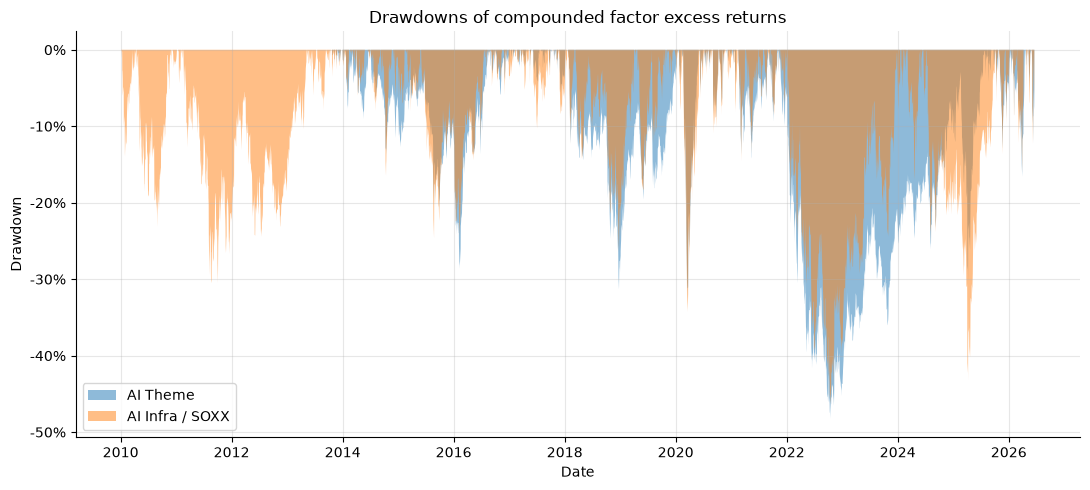

In [5]:
dd_base = factors.set_index("date")[["ai_theme_excess_return", "ai_infra_excess_return"]]
curves = (1 + dd_base).cumprod()
drawdowns = curves / curves.cummax() - 1

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(drawdowns.index, drawdowns["ai_theme_excess_return"], 0,
                alpha=0.5, label="AI Theme")
ax.fill_between(drawdowns.index, drawdowns["ai_infra_excess_return"], 0,
                alpha=0.5, label="AI Infra / SOXX")
ax.set_title("Drawdowns of compounded factor excess returns")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

## 3. Return distributions and rolling volatility

Daily return histograms (with the sample mean marked) show the shape differences directly: the semiconductor factor has both wider tails and larger single-day moves (min ≈ −15.2%, max ≈ +18.6%) than the theme basket (min ≈ −10.5%, max ≈ +12.3%).

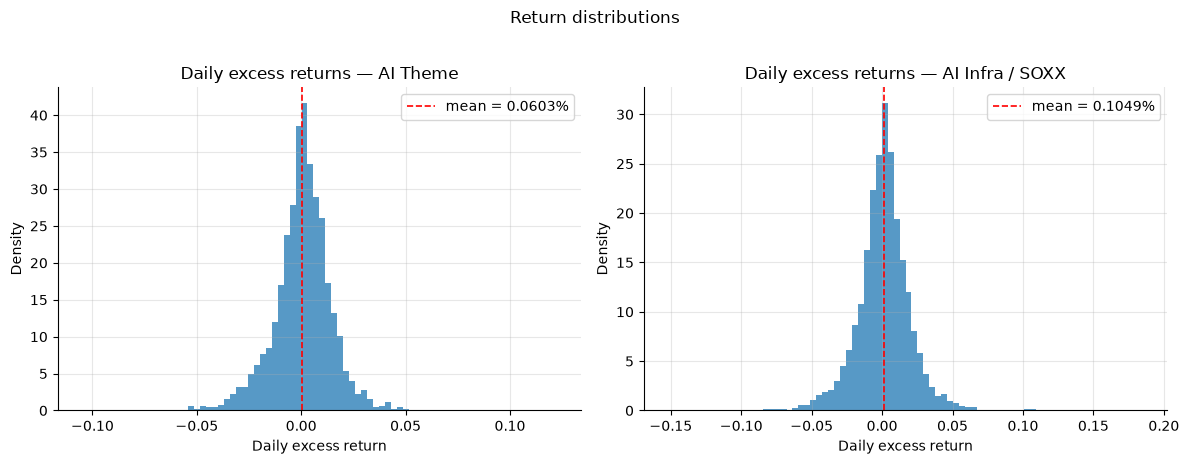

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
for ax, col, name in zip(
    axes,
    ["ai_theme_excess_return", "ai_infra_excess_return"],
    ["AI Theme", "AI Infra / SOXX"],
):
    r = factors[col].dropna()
    ax.hist(r, bins=80, alpha=0.75, density=True)
    ax.axvline(r.mean(), color="red", ls="--", lw=1.2, label=f"mean = {r.mean():.4%}")
    ax.set_title(f"Daily excess returns — {name}")
    ax.set_xlabel("Daily excess return")
    ax.set_ylabel("Density")
    ax.legend()
fig.suptitle("Return distributions", y=1.02)
plt.tight_layout()
plt.show()

Rolling **63-day** (≈ one quarter) annualized volatility:

$$\hat{\sigma}_{ann,t} = \sqrt{252}\;\text{std}\big(R^{xs}_{t-62}, \dots, R^{xs}_{t}\big)$$

Volatility is strongly time-varying and the two series move together — the COVID spike and the 2022 bear market dominate, with infra vol persistently above theme vol outside of calm periods.

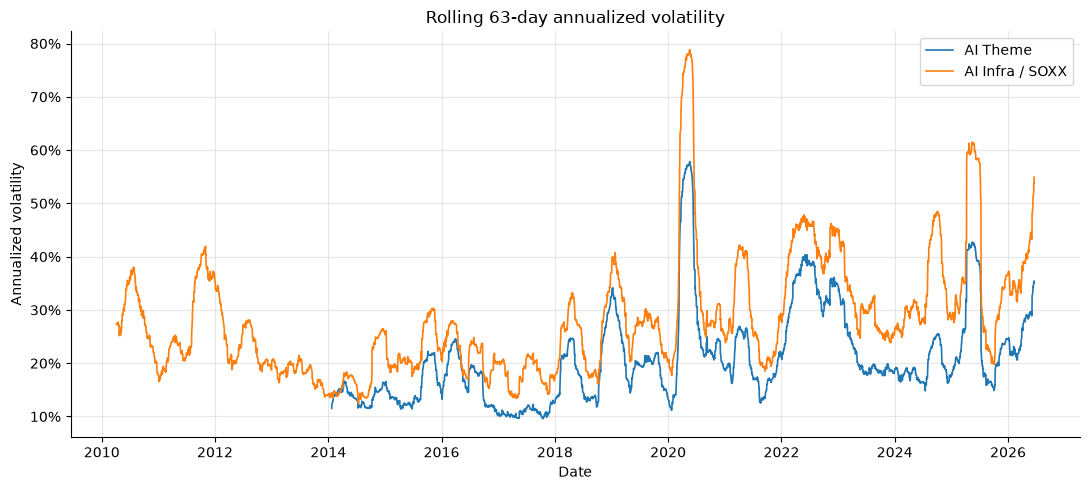

In [7]:
roll_vol = factors.set_index("date")[["ai_theme_excess_return", "ai_infra_excess_return"]] \
                  .rolling(63).std() * np.sqrt(TRADING_DAYS)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(roll_vol.index, roll_vol["ai_theme_excess_return"], label="AI Theme", lw=1.2)
ax.plot(roll_vol.index, roll_vol["ai_infra_excess_return"], label="AI Infra / SOXX", lw=1.2)
ax.set_title("Rolling 63-day annualized volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized volatility")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Correlation analysis and multicollinearity diagnostics

We correlate the two AI factors with the Fama-French factors (MKT_RF, SMB, HML, RMW, CMA, UMD) on the intersection of dates where the FF 5-factor columns are non-NaN (the FF file's 5-factor block ends 2026-05-29).

The spec's **Section 20 warning** is directly relevant here:

> *"If AI Theme and AI Infra are highly correlated, later partial betas may be unstable. This does not invalidate the factors, but it affects interpretation ... Do not interpret a low partial beta as no AI exposure if the two AI factors are highly collinear."*

> *"If the two factors are highly correlated after 2022, individual betas may become less stable. The combined two-factor AI component may be more stable than either partial beta alone."*

Correlation sample: 2013-10-23 -> 2026-05-29 (3,168 obs)


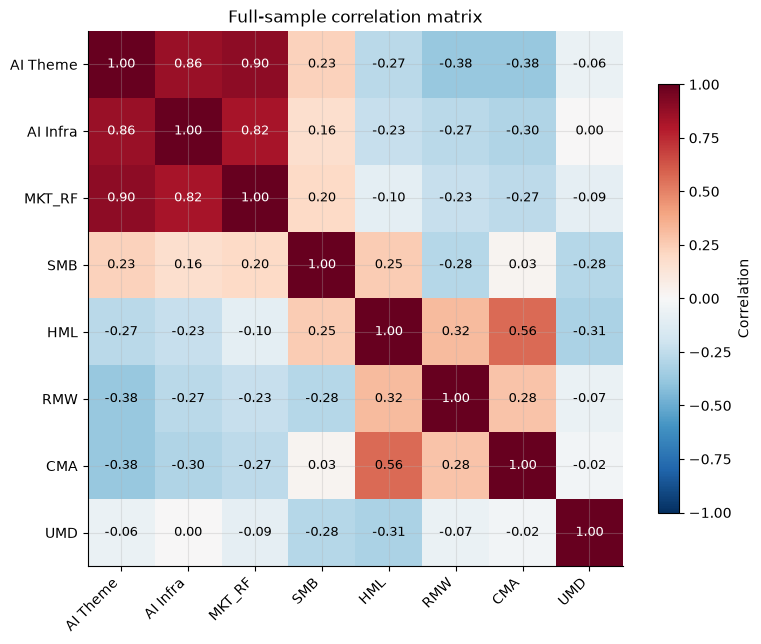

In [8]:
corr_cols = ["ai_theme_excess_return", "ai_infra_excess_return",
             "mkt_rf", "smb", "hml", "rmw", "cma", "umd"]
corr_sample = merged.dropna(subset=corr_cols)
corr_matrix = corr_sample[corr_cols].corr()

print(f"Correlation sample: {corr_sample['date'].min():%Y-%m-%d} -> "
      f"{corr_sample['date'].max():%Y-%m-%d} ({len(corr_sample):,} obs)")

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
labels = ["AI Theme", "AI Infra", "MKT_RF", "SMB", "HML", "RMW", "CMA", "UMD"]
ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)), labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center",
                fontsize=9, color="black" if abs(corr_matrix.iloc[i, j]) < 0.75 else "white")
fig.colorbar(im, ax=ax, shrink=0.8, label="Correlation")
ax.set_title("Full-sample correlation matrix")
plt.tight_layout()
plt.show()

The full-sample correlations match the pipeline diagnostics: corr(AI Theme, AI Infra) ≈ 0.86, corr with MKT_RF ≈ 0.90 (theme) and 0.83 (infra). Both AI factors load like high-beta *growth* portfolios: negative correlations with HML, RMW and CMA.

### Rolling correlation between the two AI factors

Rolling 63/126/252-day correlations show *when* the co-movement changed. The spec flags exactly this: after 2022 the two factors move nearly in lock-step, so in later firm-level regressions the individual partial betas $\beta_{AITheme}$ and $\beta_{AIInfra}$ may be individually unstable even when the joint AI component is well identified.

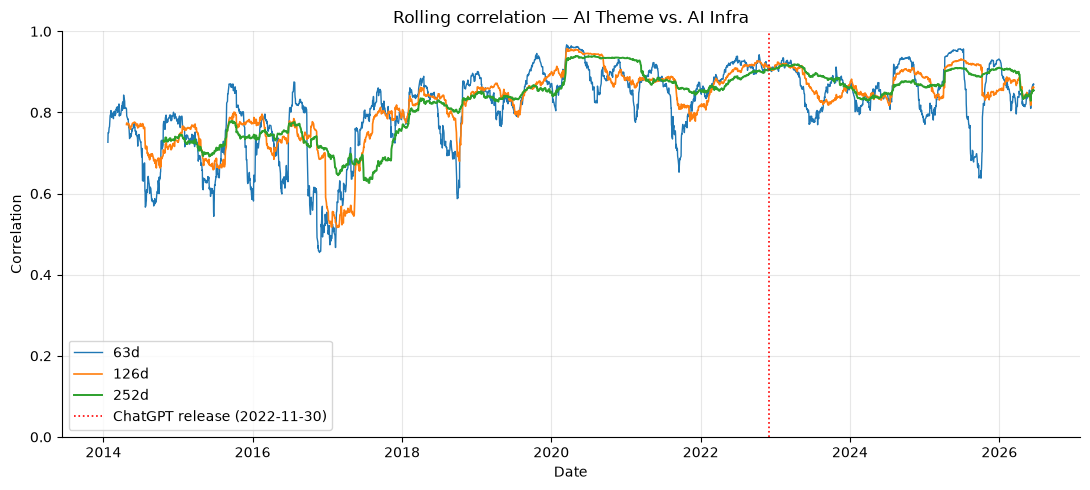

corr(theme, infra) pre-ChatGPT : 0.859 (2,292 obs)
corr(theme, infra) post-ChatGPT: 0.876 (890 obs)


In [9]:
pair = factors.set_index("date")[["ai_theme_excess_return", "ai_infra_excess_return"]].dropna()

fig, ax = plt.subplots(figsize=(11, 5))
for window, lw in [(63, 1.0), (126, 1.2), (252, 1.4)]:
    rc = pair["ai_theme_excess_return"].rolling(window).corr(pair["ai_infra_excess_return"])
    ax.plot(rc.index, rc, label=f"{window}d", lw=lw)
ax.axvline(CHATGPT_DATE, color="red", ls=":", lw=1.2, label="ChatGPT release (2022-11-30)")
ax.set_title("Rolling correlation — AI Theme vs. AI Infra")
ax.set_xlabel("Date")
ax.set_ylabel("Correlation")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

post = pair.loc[pair.index >= CHATGPT_DATE]
pre = pair.loc[pair.index < CHATGPT_DATE]
print(f"corr(theme, infra) pre-ChatGPT : {pre.corr().iloc[0, 1]:.3f} ({len(pre):,} obs)")
print(f"corr(theme, infra) post-ChatGPT: {post.corr().iloc[0, 1]:.3f} ({len(post):,} obs)")

Full-sample correlation is high in **both** regimes (≈0.86 pre-ChatGPT, ≈0.88 post), but the rolling windows reveal the dynamics: 63-day estimates average ≈0.86 post-ChatGPT, exceed 0.9 in about a third of post-2022 windows, and spike to ≈0.96 during the 2023–2026 AI rally. Practically: theme and infra increasingly price the *same* AI news, so downstream two-factor beta estimates should be read jointly (and their sum is more robust than either coefficient alone).

## 5. Factor regressions

We regress each AI factor on standard factors to ask: **how much of the AI factor is just market/style exposure, and what residual (alpha) is left?**

Two specifications, each estimated on the full sample and on the post-ChatGPT subsample (t ≥ 2022-11-30):

1. **CAPM:** $\quad R^{xs}_{AI,t} = \alpha + \beta_{mkt}\,\text{MKT\_RF}_t + \varepsilon_t$
2. **FF5 + UMD:** $\quad R^{xs}_{AI,t} = \alpha + \beta_{mkt}\,\text{MKT\_RF}_t + s\,\text{SMB}_t + h\,\text{HML}_t + r\,\text{RMW}_t + c\,\text{CMA}_t + m\,\text{UMD}_t + \varepsilon_t$

Estimated by OLS with **Newey–West HAC standard errors** (5 lags) — daily factor returns are heteroskedastic and mildly autocorrelated, so plain OLS t-stats would overstate significance. Alphas are reported annualized (×252). The FF5+UMD spec is restricted to dates with non-NaN 5-factor data.

In [10]:
def run_ols(df: pd.DataFrame, y: str, xs: list[str]):
    d = df.dropna(subset=[y] + xs)
    X = sm.add_constant(d[xs])
    res = sm.OLS(d[y], X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
    return res, len(d)


SPECS = [("CAPM", ["mkt_rf"]), ("FF5+UMD", ["mkt_rf", "smb", "hml", "rmw", "cma", "umd"])]
FACTOR_NAMES = {"ai_theme_excess_return": "AI Theme", "ai_infra_excess_return": "AI Infra"}
ALL_BETAS = ["mkt_rf", "smb", "hml", "rmw", "cma", "umd"]


def regression_table(df: pd.DataFrame) -> pd.DataFrame:
    rows = {}
    for y, yname in FACTOR_NAMES.items():
        for spec_name, xs in SPECS:
            res, n = run_ols(df, y, xs)
            rows[f"{yname} | {spec_name}"] = {
                "alpha_ann": res.params["const"] * TRADING_DAYS,
                "t(alpha)": res.tvalues["const"],
                **{f"b_{x}": res.params.get(x, np.nan) for x in ALL_BETAS},
                "R2": res.rsquared,
                "N": n,
            }
    return pd.DataFrame(rows).T


reg_full = regression_table(merged)
print("=== Full sample ===")
reg_full

=== Full sample ===


,alpha_ann,t(alpha),b_mkt_rf,b_smb,b_hml,b_rmw,b_cma,b_umd,R2,N
AI Theme | CAPM,0.0074,0.2654,1.1382,NaN,NaN,NaN,NaN,NaN,0.8015,"3,168.0000"
AI Theme | FF5+UMD,0.0245,1.0646,1.0514,0.1551,-0.2530,-0.2921,-0.1422,-0.0282,0.8579,"3,168.0000"
AI Infra | CAPM,0.0670,1.6657,1.3995,NaN,NaN,NaN,NaN,NaN,0.6826,"4,125.0000"
AI Infra | FF5+UMD,0.0689,1.7445,1.3616,0.1474,-0.3431,-0.0824,-0.0510,0.0643,0.7087,"4,125.0000"


In [11]:
reg_post = regression_table(merged.loc[merged["date"] >= CHATGPT_DATE])
print(f"=== Post-ChatGPT subsample (>= {CHATGPT_DATE:%Y-%m-%d}) ===")
reg_post

=== Post-ChatGPT subsample (>= 2022-11-30) ===


,alpha_ann,t(alpha),b_mkt_rf,b_smb,b_hml,b_rmw,b_cma,b_umd,R2,N
AI Theme | CAPM,0.0558,1.1190,1.3799,NaN,NaN,NaN,NaN,NaN,0.8491,876.0000
AI Theme | FF5+UMD,0.0551,1.4021,1.2083,0.0957,-0.2459,-0.3951,-0.1225,0.0557,0.9001,876.0000
AI Infra | CAPM,0.1639,1.5200,1.8335,NaN,NaN,NaN,NaN,NaN,0.6534,876.0000
AI Infra | FF5+UMD,0.1577,1.5620,1.7230,0.0029,-0.3739,-0.2285,0.2171,0.2660,0.6889,876.0000


In [12]:
# Headline numbers used in the interpretation below (computed, not hard-coded).
for label, tbl in [("full sample", reg_full), ("post-ChatGPT", reg_post)]:
    print(f"--- {label} ---")
    for idx, row in tbl.iterrows():
        print(f"{idx:22s} alpha_ann={row['alpha_ann']:+.2%} (t={row['t(alpha)']:+.1f}), "
              f"b_mkt={row['b_mkt_rf']:.2f}, R2={row['R2']:.2f}, N={int(row['N'])}")

--- full sample ---
AI Theme | CAPM        alpha_ann=+0.74% (t=+0.3), b_mkt=1.14, R2=0.80, N=3168
AI Theme | FF5+UMD     alpha_ann=+2.45% (t=+1.1), b_mkt=1.05, R2=0.86, N=3168
AI Infra | CAPM        alpha_ann=+6.70% (t=+1.7), b_mkt=1.40, R2=0.68, N=4125
AI Infra | FF5+UMD     alpha_ann=+6.89% (t=+1.7), b_mkt=1.36, R2=0.71, N=4125
--- post-ChatGPT ---
AI Theme | CAPM        alpha_ann=+5.58% (t=+1.1), b_mkt=1.38, R2=0.85, N=876
AI Theme | FF5+UMD     alpha_ann=+5.51% (t=+1.4), b_mkt=1.21, R2=0.90, N=876
AI Infra | CAPM        alpha_ann=+16.39% (t=+1.5), b_mkt=1.83, R2=0.65, N=876
AI Infra | FF5+UMD     alpha_ann=+15.77% (t=+1.6), b_mkt=1.72, R2=0.69, N=876


**Interpretation** (numbers below from the printed headline table)

- **Market beta dominates.** Full-sample MKT betas are ≈1.14 (theme) and ≈1.40 (infra) under CAPM, with $R^2$ of 0.80 and 0.68 respectively — the AI factors are first and foremost high-beta equity exposure. FF5+UMD raises $R^2$ to 0.86 (theme) and 0.71 (infra), trimming the market betas to ≈1.05 and ≈1.36.
- **Style tilts:** negative HML/RMW/CMA loadings confirm the growth / low-profitability / low-investment tilt typical of AI-theme portfolios; SMB loadings are small.
- **Residual alpha:** the theme basket is almost fully explained — CAPM alpha is +0.7%/yr (t = 0.3) and FF5+UMD alpha +2.5%/yr (t = 1.1). The infra factor keeps a larger residual, ≈+6.7–6.9%/yr, but only borderline significant (t ≈ 1.7) under Newey–West errors. In other words, most of the AI factors' average return is standard factor exposure plus beta; the idiosyncratic "AI signal" is concentrated in the semiconductor leg and is statistically modest.
- **Post-ChatGPT:** market betas *rise* (theme ≈1.38, infra ≈1.83 under CAPM) and annualized alphas increase sharply (theme ≈+5.6%, infra ≈+16.4%) — consistent with a genuine AI-specific repricing on top of higher beta. With only ~3.5 years (~876 daily obs) in the subsample, t-stats remain ≤1.6, so these alphas are suggestive rather than established.
- **Caveat (spec §20):** with corr(theme, infra) ≈ 0.9 in the post-2022 period, firm-level regressions using *both* factors simultaneously will have unstable partial betas; interpret their sum, or orthogonalize, rather than each coefficient separately.

## 6. Regime analysis: pre- vs post-ChatGPT

ChatGPT's release (2022-11-30) is the natural date at which "AI" became a priced macro narrative. We split the sample there and recompute the performance statistics for both factors.

In [13]:
def regime_stats(df: pd.DataFrame, col: str, mask: pd.Series) -> pd.Series:
    r = df.loc[mask, col].dropna()
    return pd.Series({
        "obs": len(r),
        "ann_mean": r.mean() * TRADING_DAYS,
        "ann_vol": r.std() * np.sqrt(TRADING_DAYS),
        "sharpe": r.mean() / r.std() * np.sqrt(TRADING_DAYS),
        "max_drawdown": max_drawdown(r),
    })


pre_mask = factors["date"] < CHATGPT_DATE
post_mask = factors["date"] >= CHATGPT_DATE

regimes = pd.DataFrame({
    "Theme | pre": regime_stats(factors, "ai_theme_excess_return", pre_mask),
    "Theme | post": regime_stats(factors, "ai_theme_excess_return", post_mask),
    "Infra | pre": regime_stats(factors, "ai_infra_excess_return", pre_mask),
    "Infra | post": regime_stats(factors, "ai_infra_excess_return", post_mask),
})
regimes

,Theme | pre,Theme | post,Infra | pre,Infra | post
obs,"2,292.0000",890.0000,"3,249.0000",890.0000
ann_mean,0.1043,0.2748,0.2003,0.4982
ann_vol,0.2214,0.2394,0.2839,0.3661
sharpe,0.4710,1.1477,0.7056,1.3608
max_drawdown,-0.4822,-0.2803,-0.4639,-0.4330


Both factors earned dramatically higher annualized excess returns post-ChatGPT: the theme basket went from ≈10.4%/yr (Sharpe ≈0.47) to ≈27.5%/yr (Sharpe ≈1.15), and the infra factor from ≈20.0%/yr (Sharpe ≈0.71) to ≈49.8%/yr (Sharpe ≈1.36). Volatility also rose in the post regime (theme 22.1% → 23.9%, infra 28.4% → 36.6%), but returns rose far more, so Sharpe ratios roughly doubled. Caveat: the "post" window is short (~3.5 years) and contains a single dominant AI bull market, so these subsample means are not stationary estimates — they describe one episode, not a long-run premium.

## 7. Robustness: SOXX vs. SMH for the infrastructure factor

The spec (§ "Recommended robustness variant" for the infra factor) requires checking whether results depend on the exact semiconductor ETF:

> *"Use a second dedicated semiconductor ETF as a robustness alternative. If the main results depend heavily on the exact semiconductor ETF choice, the AI Infra beta should be interpreted cautiously."*

Per `config/semicond_etf_choice.txt`, **SOXX** is the primary ETF and **SMH** the alternative. We rebuild the SMH-based variant offline from the raw ETF return file:

$$F^{SMH}_{AIInfra,t} = R_{SMH,t} - R_{f,t}$$

For the daily risk-free rate we use the stored `rf_rate` column, which is now populated for the full sample (see the data notes in Section 1). We then compare the variant to the stored SOXX-based factor.

corr(stored infra ETF return, raw SOXX return) = 1.000000  (identity check)
corr(SOXX-based infra factor, SMH-based variant) = 0.9838 (4,139 obs, 2010-01-05 -> 2026-06-18)
SMH variant: ann. mean 27.19%, ann. vol 29.18%
SOXX factor: ann. mean 26.44%, ann. vol 30.35%


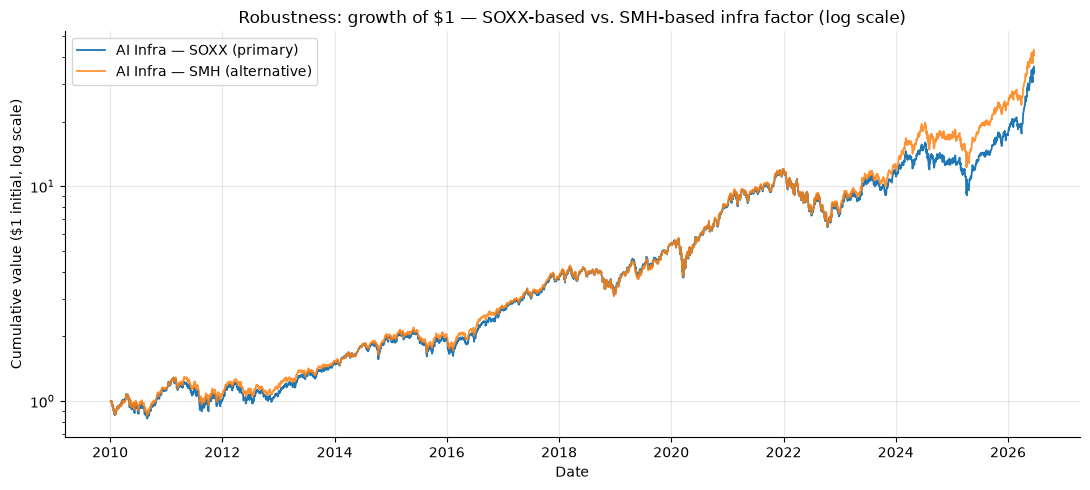

In [14]:
etf = pd.read_feather(DATA / "raw" / "etf_returns" / "etf_returns.feather")
# Raw ETF dates are tz-aware (US/Eastern); normalize to tz-naive midnight like the pipeline does.
etf["date"] = pd.to_datetime(etf["date"], utc=True).dt.tz_localize(None).dt.normalize()

smh = (etf.loc[etf["ticker"] == "SMH", ["date", "return"]]
          .rename(columns={"return": "smh_return"}))
soxx = (etf.loc[etf["ticker"] == "SOXX", ["date", "return"]]
           .rename(columns={"return": "soxx_return"}))

rob = (factors[["date", "rf_rate", "ai_infra_excess_return", "ai_infra_etf_return"]]
       .merge(smh, on="date", how="left")
       .merge(soxx, on="date", how="left"))
rob["smh_excess"] = rob["smh_return"] - rob["rf_rate"]

# Sanity check: the stored infra ETF return should be exactly the SOXX raw return.
soxx_check = rob[["ai_infra_etf_return", "soxx_return"]].dropna().corr().iloc[0, 1]
pair = rob[["date", "ai_infra_excess_return", "smh_excess"]].dropna()
corr_soxx_smh = pair[["ai_infra_excess_return", "smh_excess"]].corr().iloc[0, 1]

print(f"corr(stored infra ETF return, raw SOXX return) = {soxx_check:.6f}  (identity check)")
print(f"corr(SOXX-based infra factor, SMH-based variant) = {corr_soxx_smh:.4f} "
      f"({len(pair):,} obs, {pair['date'].min():%Y-%m-%d} -> {pair['date'].max():%Y-%m-%d})")
print(f"SMH variant: ann. mean {pair['smh_excess'].mean() * TRADING_DAYS:.2%}, "
      f"ann. vol {pair['smh_excess'].std() * np.sqrt(TRADING_DAYS):.2%}")
print(f"SOXX factor: ann. mean {pair['ai_infra_excess_return'].mean() * TRADING_DAYS:.2%}, "
      f"ann. vol {pair['ai_infra_excess_return'].std() * np.sqrt(TRADING_DAYS):.2%}")

cum = (1 + pair[["ai_infra_excess_return", "smh_excess"]]).cumprod()
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(pair["date"], cum["ai_infra_excess_return"], label="AI Infra — SOXX (primary)", lw=1.3)
ax.plot(pair["date"], cum["smh_excess"], label="AI Infra — SMH (alternative)", lw=1.3, alpha=0.85)
ax.set_yscale("log")
ax.set_title("Robustness: growth of $1 — SOXX-based vs. SMH-based infra factor (log scale)")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative value ($1 initial, log scale)")
ax.legend()
plt.tight_layout()
plt.show()

The two semiconductor variants are near-identical: daily correlation ≈ 0.98 over the full 2010–2026 sample, and closely tracking cumulative paths (SMH's slightly higher annualized mean — ≈27.2% vs ≈26.4% — and lower vol reflect its somewhat different composition, e.g. heavier NVIDIA weighting vs. SOXX's modified cap weights). **Conclusion per the spec:** the AI Infra factor does *not* depend heavily on the exact ETF choice, so the infra beta can be interpreted without this caveat. The identity check also confirms the stored infra factor is exactly SOXX minus the daily risk-free rate.

## 8. Pipeline diagnostics

For reference, the flat diagnostic table produced by the construction pipeline itself (`data/diagnostics/factor_summary.feather`, 37 metrics). The values match the statistics recomputed above, which serves as an independent cross-check of this notebook's calculations.

In [15]:
diag = pd.read_feather(DATA / "diagnostics" / "factor_summary.feather")
diag

,metric,value
0,ai_theme_count,"3,182.0000"
1,ai_theme_mean,0.0006
2,ai_theme_std,0.0143
3,ai_theme_min,-0.1053
4,ai_theme_max,0.1227
5,ai_theme_skewness,-0.2146
6,ai_theme_kurtosis,5.6667
7,ai_theme_sharpe,0.0422
8,ai_theme_annualized_vol,0.2266
9,ai_theme_rolling_vol_63d,0.2080


## 9. Key takeaways

- **Two distinct but highly correlated AI factors.** AI Theme (basket of 7 AI-theme ETFs, 3,182 obs from Oct 2013) earned ≈15.2% ann. excess return at ≈22.7% vol; AI Infra (SOXX, 4,139 obs from Jan 2010) earned ≈26.4% at ≈30.4% vol. Full-sample correlation is ≈0.86 (≈0.88 post-ChatGPT, with short windows spiking to ≈0.96).
- **Mostly beta, some alpha.** CAPM/FF5+UMD regressions with Newey–West errors give full-sample market betas of ≈1.1 (theme) and ≈1.4 (infra) with $R^2$ of 0.68–0.86. The theme basket's alpha is statistically indistinguishable from zero; the infra factor retains ≈+7%/yr of borderline-significant alpha. Post-ChatGPT, both betas and alphas rise sharply (infra alpha ≈+16%/yr), but the short subsample keeps t-stats below conventional significance.
- **Multicollinearity caveat (spec §20).** Post-2022 co-movement means firm-level partial betas on the two factors will be individually unstable when both are included; interpret the combined AI component (or orthogonalized variants) rather than either coefficient alone.
- **Regime shift.** Pre/post-ChatGPT splits show annualized excess returns roughly 2.5× higher after 2022-11-30 (theme 10.4% → 27.5%, infra 20.0% → 49.8%), but the post window is short and single-episode — subsample means should not be extrapolated as a permanent premium.
- **Robustness confirmed.** The SMH-based infra variant correlates ≈0.98 with the SOXX-based factor over the full sample, so the infra factor is insensitive to the semiconductor ETF choice, as the spec requires.
- **Documented limitations.** (1) Only **current** AUM is available, so theme-basket weights use today's AUM across the whole history (point-in-time AUM is a planned Phase 2 improvement); point-in-time *inclusion* is nonetheless correct because ETFs enter only when return data exists. (2) The daily risk-free rate is annual-rate/252 — an earlier pipeline bug subtracted the annual rate from daily returns and has been fixed. (3) Two construction artifacts surfaced during this analysis — a NaN `rf_rate` column before 2013-11-01 (with 19 missing Jan-2010 infra obs) and an exact-zero theme row on ROBO's inception day — have since been fixed in the pipeline (45-day rf forward-fill lookback; `min_count=1` aggregation); the current file has no NaN risk-free rates and no zero-artifact rows. (4) FF 5-factor data ends 2026-05-29, so style regressions stop there even though the factor series runs to 2026-06-18.